# PROCEDURE

## Description

 - Define the list of OSM `tags` to be included in the analysis
 - Define a EU study area `sa` by drawing a polygon at [geojson.io](http://geojson.io/#map=2/0/20)
 - Retrive satellite `products` from SentinelSat within `sa`, defining a time slice (fixed?)
 - Get the list of NUTS4 names `nuts_name` (PostGIS or EuroStat) within `sa`
 - Retrive OSM data for all `tags` for each `nuts_name`
 - Create annotations for `DL-model` using (Yolo/any) defined standard
 - Split `train` / `validation` / `testing`
 - Train the `DL-model`
 - Evaluate results on `testing` images

## Links

 - pyGIS :: https://pygis.io/docs/e_new_vectors.html# <br>

## Libraries

<b style="color:green">NOTES</b> <br>
 - when trying to uninstall you might get permission errors on files, restart the kernel since they could be in use in current notebook
 - ...

### Install

In [ ]:
pip show numpy

In [ ]:
pip show shapely

In [ ]:
pip show osmnx

In [ ]:
pip install tqdm

Installations that must be tested again:

### Load

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sentinelsat import SentinelAPI, read_geojson, geojson_to_wkt
from datetime import date

In [ ]:
import rioxarray
import geopandas as gpd
import rasterio as rio

In [ ]:
from matplotlib import pyplot
from rasterio.plot import show

In [ ]:
from sqlalchemy import create_engine # query PostGIS
from sqlalchemy import inspect

In [ ]:
import osmnx as ox

In [ ]:
from shapely.geometry import Polygon, box
import shapely.ops as so

In [ ]:
import json

In [ ]:
import os
from pathlib import Path
import fnmatch
import glob

In [ ]:
from osgeo import gdal

In [ ]:
import random

In [ ]:
import shutil

In [ ]:
from tqdm import tqdm
import time

## Study Area

In [ ]:
# sa_fil = "italy_center_south.geojson"
sa_fil = "naples_metropolytan.geojson"

In [ ]:
sa_j = read_geojson(sa_fil)

In [ ]:
type(sa_j)

In [ ]:
sa = geopandas.read_file(sa_fil)

In [ ]:
type(sa)

In [ ]:
sa.plot()

## Prisma
https://www.asi.it/scienze-della-terra/prisma/

## SpaceNet
 - https://spacenet.ai/challenges/
 - https://spacenet.ai/sn7-challenge/

### Download data

```BASH
# run from within Mac terminal after configuring credentials:
aws s3 cp s3://spacenet-dataset/spacenet/SN7_buildings/tarballs/SN7_buildings_test_public.tar.gz spacenet/SN7/
aws s3 cp s3://spacenet-dataset/spacenet/SN7_buildings/tarballs/SN7_buildings_train.tar.gz spacenet/SN7/
aws s3 cp s3://spacenet-dataset/spacenet/SN7_buildings/tarballs/SN7_buildings_train_csvs.tar.gz spacenet/SN7/
```

## SentinelHub
 - [GitHub](https://github.com/sentinel-hub)
 - [User dashboard](https://apps.sentinel-hub.com/dashboard/#/configurations/92da91b8-dd15-4d37-a6e6-95bea2ef0796)

## SentinelSat
 - [GitHub](https://github.com/sentinelsat/sentinelsat)
 - [ReadTheDocs](https://sentinelsat.readthedocs.io/en/stable/api_overview.html#lta-products)
 

### Geospatial raster and Vector data with Python

 - [EGU short course 2023](https://github.com/esciencecenter-digital-skills/2023-04-25-ds-geospatial-python-EGU)

### Check out `RapidEye time series for Sentinel-2`

 - [ESA link](https://earth.esa.int/eogateway/catalog/rapideye-time-series-for-sentinel-2)

### Credentials / API

In [ ]:
sentinelsat_credentials_file = "sentinelsat_credentials.json"

In [ ]:
# Opening JSON file
with open( sentinelsat_credentials_file ) as json_file:
    sensat = json.load(json_file)
 
    # Print the type of data variable
#    print("Type:", type(data))
 
    # Print the data of dictionary
#    print("\nUser      :", data['user'])
#    print("\nPassword  :", data['password'])

In [ ]:
user = sensat['user']
pswd = sensat['password']
sentinelSat_endpoint = "https://apihub.copernicus.eu/apihub"

In [ ]:
api = SentinelAPI(user, pswd, sentinelSat_endpoint)

In [ ]:
api.session

### Request Sat Products

In [ ]:
date_FROM = date(2023,4,1)
date_TO   = date(2023,5,1)

In [ ]:
platform_name = "Sentinel-2"

In [ ]:
cloud_coverage = (0,10)

In [ ]:
# search by polygon, time, and SciHub query keywords
products = api.query( geojson_to_wkt(sa_j),
                      date = ( date_FROM, date_TO ),
                      platformname = platform_name,
                      cloudcoverpercentage = cloud_coverage
                    )

In [ ]:
len(products)

### GeoDataFrame from Products

In [ ]:
gdf = api.to_geodataframe(products)

In [ ]:
type(gdf)

In [ ]:
gdf.head(1)

In [ ]:
gdf.plot()

In [ ]:
gdf.bounds

### Select Products

Get the list of first 5 keys:

In [ ]:
list(products.keys())[0:5]

Select only the first product:

In [ ]:
sel_products = dict(list(products.items())[:1])

In [ ]:
api.get_product_odata( list(sel_products.keys())[0] )

In [ ]:
api.to_geodataframe(sel_products)

#### Save GeoDF

In [ ]:
sel_prod_gdf = api.to_geodataframe(sel_products)

In [ ]:
sel_prod_gdf.to_file("sel_products.geojson",driver="GeoJSON")

### Download Selected Products

In [ ]:
# Activate only if required:
# api.download_all(sel_products,directory_path="data/")

### Map Selected Products

In [ ]:
ras_path_20m = "data/S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004.SAFE/GRANULE/L1C_T33TVF_A040974_20230427T095813/IMG_DATA/"

In [ ]:
raster = rioxarray.open_rasterio(ras_path_20m + "T33TVF_20230427T095031_TCI.jp2")

In [ ]:
raster

In [ ]:
raster.rio.crs

In [ ]:
raster.plot()

In [ ]:
raster.plot.imshow()

### Get Sentinel-2 tiling grid

In [ ]:
!wget https://sentinel.esa.int/documents/247904/1955685/S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml

In [ ]:
s2_tile_grid = geopandas.read_file("S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml")

In [ ]:
s2_tile_grid.head(20).plot()

## NUTS4 | EuroStat

https://ec.europa.eu/eurostat/web/gisco/geodata/reference-data/administrative-units-statistical-units/nuts

Consider to retrive data from API <br>
https://ec.europa.eu/eurostat/web/main/data/web-services

## NUTS4 | PostGIS

### Get list of NUTS4 within Study Area (sa)

#### Source: LandSupport DEV
 - reference code is in [LTM_ADVANCED_EU.ipynb](http://192.168.30.11:8888/notebooks/release/work/repo/middleware/api/PPProcessor/jupyter/management/LTM_ADVANCED_EU.ipynb) <br>
 - reference lib in in [psql_lib.ipynb](http://192.168.30.11:8888/notebooks/release/work/repo/middleware/api/PPProcessor/jupyter/lib/psql_lib.ipynb) (which I should download locally as `psql_lib.py`)

##### Using LandSupport lib | DEPRECATED

##### Using GeoPandas | easiest way

In [ ]:
import os
db_connection_url = os.environ["LANDSUPPORT_URL"]
con = create_engine(db_connection_url)  

In [ ]:
sa.geometry

In [ ]:
sql = """
SELECT nuts_name,geom
	FROM public.nuts_4_2013 a
	WHERE ST_Intersects( a.geom, ST_GeomFromText('""" + str(sa.geometry[0]) + """',4326)
					 )
"""
sql

In [ ]:
cities_gdf = gpd.read_postgis(sql, con)

In [ ]:
cities_gdf

In [ ]:
cities_gdf["nuts_name"][0]

### Get list of NUTS4 within Products

#### To be done...

## OSM | retrieve tags

 - [Wiki Overpass API](https://wiki.openstreetmap.org/wiki/Overpass_API#Building_blocks)
 - [Python Overpass API](https://python-overpy.readthedocs.io/en/latest/example.html)
 - [Loading data from OSM with Python and the Overpass API](https://towardsdatascience.com/loading-data-from-openstreetmap-with-python-and-the-overpass-api-513882a27fd0)
 - [PyGIS - Accessing OSM data in python](https://pygis.io/docs/d_access_osm.html)
 - [OSM tags Wiki](https://wiki.openstreetmap.org/wiki/Tags)
 - [OSM and urban data, in book "Geospatial Analysis with Python and R"](https://kodu.ut.ee/~kmoch/geopython2021/L4/osm-urban.html)

### Get BBox from Selected Products

#### Load GeoDF

In [ ]:
sel_prod_gdf = geopandas.read_file("sel_products.geojson")

#### Check GeoDF

In [ ]:
sel_prod_gdf

In [ ]:
type(sel_prod_gdf)

### TAGS definition

#### Buildings

In [ ]:
# List key-value pairs for tags
tags = {'building': True}   

### Convert GeoDataFrame geometry (polygon / multipolygon) into Shapely polygon

#### Use the Products bounding box | too large | <i style="color:magenta">not working</b>

In [ ]:
x,y = sel_prod_gdf.explode(index_parts=False).geometry[0].exterior.coords.xy

In [ ]:
sel_prod_pol = Polygon(list(zip(x, y)))

In [ ]:
sel_prod_pol

Retrieve OSM data

In [ ]:
osm_data = ox.geometries_from_polygon( sel_prod_pol, tags )

Save OSM data

In [ ]:
osm_data.to_file("osm_data/buildings.geojson", driver='GeoJSON')

#### Use the Study Area bounding box | smaller | <i style="color:magenta">not working</b>

In [ ]:
x,y = sa.explode(index_parts=False).geometry[0].exterior.coords.xy

In [ ]:
sel_prod_pol = Polygon(list(zip(x, y)))

In [ ]:
sel_prod_pol

Retrieve OSM data

In [ ]:
osm_data = ox.geometries_from_polygon( sel_prod_pol, tags )

Save OSM data

In [ ]:
osm_data.to_file("osm_data/buildings.geojson", driver='GeoJSON')

### Use PostGIS cities within Products bounding box

#### Retrieve OSM data

In [ ]:
osm_data = ox.geometries_from_place( cities_gdf["nuts_name"][0], tags )

In [ ]:
osm_data.head(3).plot()

In [ ]:
osm_data.head(3)

#### Save OSM data

In [ ]:
fname = "osm_data/buildings__" + cities_gdf["nuts_name"][0] + ".geojson"
osm_data.to_file( fname, driver='GeoJSON' )

#### OSM data :: BATCH retrieve + save

In [ ]:
dir_osmdata = "osm_data/"

In [ ]:
tags

In [ ]:
osm_data = ox.geometries_from_place( 'Moschiano', tags )

In [ ]:
len(osm_data)

In [ ]:
for row, fields in cities_gdf.iterrows():
    Found = False
    for filename in os.listdir( dir_osmdata ):
        if filename.startswith( "buildings__" ):
            if fnmatch.fnmatch( filename, 'buildings__' + fields[0] + '.geojson' ):
                print( "%04d" % row, "%40s" % fields[0], '  [existent]')
                Found = True
    if not Found:
        try:
            print( "%04d" % row, "%40s" % fields[0], '  [downloading]' )
            osm_data = ox.geometries_from_place( fields[0], tags )
            if not len(osm_data)==0:
                fname = dir_osmdata + "buildings__" + fields[0] + ".geojson"
                osm_data.to_file( fname, driver='GeoJSON' )
            else:
                print("%45s" % "Skipped because it's empty.")
        except OSError as err:
            print("  OS error:", err)
        except ValueError:
            print("%45s" % "Could not find.")
        except Exception as err:
            print(f"  Unexpected {err=}, {type(err)=}")
            raise

#### OSM data :: MANUAL psql insert

In [ ]:
dir_osmdata = "osm_data/"
tag = "buildings"
CRS = 4326
geom_used = ["Polygon", "MultiPolygon"]

In [ ]:
filename = 'buildings__Afragola.geojson'

In [ ]:
city = filename.split("__")[1].split(".geo")[0]
city

In [ ]:
#tmp = geopandas.read_file("osm_data/buildings__Lettere.geojson")
tmp = geopandas.read_file( dir_osmdata + filename )

In [ ]:
tmp.head(1)

In [ ]:
tmp[tmp["addr:city"]==city].shape

In [ ]:
tmp["addr:city"]=city

In [ ]:
tmp[tmp["addr:city"]==city].shape

In [ ]:
geom_types = tmp.geometry.type.unique()
for g in geom_types:
    nrows = tmp[tmp.geometry.type==g].shape[0]
    if g in geom_used:
        print( "  > " + g + " [included %d]" % nrows )
    else:
        print( "  > " + g + " [discarded] %d]" % nrows )
        tmp = tmp.drop( tmp[tmp.geometry.type==g].index )

In [ ]:
from impervious.config import pg_url  # connessione da .env
db_connection_url = pg_url()
con = create_engine(db_connection_url)

In [ ]:
# test connection
inspector = inspect(con)
print( inspector.get_schema_names() )
print( inspector.get_table_names( 'public' ) )

In [ ]:
tbl_names = inspector.get_table_names( 'public' )
tbl_names

In [ ]:
if tag in tbl_names:
    print('Found table *%s* in db:OSM schema:public' % tag)

In [ ]:
tmp.to_postgis("buildings", con, schema="public", if_exists='append', index=True) #, dtype={'geometry': Geometry('POLYGON', srid=4326)})

#### OSM data :: BATCH psql insert

##### fix issues before I could run the bathc procedure below

ISSUE #01 :: geojson files have different sets of columns

In [ ]:
#contact:housenumber

In [ ]:
a = geopandas.read_file("osm_data/buildings__Angri.geojson")
b = geopandas.read_file("osm_data/buildings__Afragola.geojson")

In [ ]:
a.head(1)

In [ ]:
b.head(1)

In [ ]:
a.shape

In [ ]:
b.shape

In [ ]:
ac = list(a.columns)
bc = list(b.columns)

In [ ]:
ac

In [ ]:
bc

In [ ]:
# setxor:
set(ac).symmetric_difference(bc)

**Final remark:**
I decide to keep only few columns to avoid wasting time.

In [ ]:
column_used = ['element_type','osmid','nodes','building','addr:city','geometry']

In [ ]:
a[column_used].shape

In [ ]:
b[column_used].shape

In [ ]:
c = b.drop(columns='osmid')

In [ ]:
c[column_used].shape

In [ ]:
c.shape

In [ ]:
list( set(list(c.columns)) & set(column_used) )

In [ ]:
# change a | b | c below in *.columns:
if len(list( set(list(c.columns)) & set(column_used) )) < len(column_used):
    print('error')
else:
    print('good')

In [ ]:
# columns that are missing in c.columns compared to column_used:
not_found = list(set(column_used) - set(c.columns))
not_found

In [ ]:
c.insert(loc=len(c.columns),column='osmid',value=None)

In [ ]:
# columns that are missing in c.columns compared to column_used:
not_found = list(set(column_used) - set(c.columns))
not_found

In [ ]:
c = b.drop(columns=['osmid','nodes'])
not_found = list(set(column_used) - set(c.columns))
print(not_found)
for nf in not_found:
    c.insert(loc=len(c.columns)-1,column=nf,value=None)

not_found = list(set(column_used) - set(c.columns))
print(not_found)

##### Run BATCH

Database pgis-osm installed in docker on Pedometrics-VM

In [ ]:
dir_osmdata = "osm_data/"
tag = "buildings"
CRS = 4326
geom_used = ["Polygon", "MultiPolygon"]
column_used = ['element_type','osmid','nodes','building','addr:city','geometry']

In [ ]:
from impervious.config import pg_url  # connessione da .env
row=0
tmp = filename = None

try:
    db_connection_url = pg_url()
    con = create_engine(db_connection_url)
    # test connection
    inspector = inspect(con)
    tbl_names = inspector.get_table_names( 'public' )
    if tag in tbl_names:
        print('Found table *%s* in db:OSM schema:public' % tag)
    else:
        print('Table *%s* not found in db:OSM schema:public' % tag)
except OSError as err:
    print("  OS error:", err)
except ValueError:
    print("%45s" % "Could not connect to postGIS")
except Exception as err:
    print(f"  Unexpected {err=}, {type(err)=}")
    raise


for filename in os.listdir( dir_osmdata ):
    if filename.startswith( tag + "__" ):
        row = row +1
        try:
            print( "%04d" % row, "%40s" % filename, ' ...' )

            # step #00 :: Read geojson
            tmp = geopandas.read_file( dir_osmdata + filename )
            
            # step #01 :: select column names
            not_found = list(set(column_used) - set(tmp.columns))
            for nf in not_found:
                print( "  > add missing column %s" % nf )
                tmp.insert(loc=len(tmp.columns)-1,column=nf,value=None)

            not_found = list(set(column_used) - set(c.columns))
            if not len(not_found)==0:
                print('Tag: %s, City: %s :: skipped for issues on missing columns')
                continue
            
            tmp = tmp[column_used]
            
            # step #02 :: write city name, unfortunately it is often/always missing
            city = filename.split("__")[1].split(".geo")[0]
            tmp["addr:city"]=city
            
            # step 03 :: discard geometries not included in 'geom_used'
            geom_types = tmp.geometry.type.unique()
            for g in geom_types:
                nrows = tmp[tmp.geometry.type==g].shape[0]
                if g in geom_used:
                    print( "  > " + g + " [included %d]" % nrows )
                else:
                    print( "  > " + g + " [discarded] %d]" % nrows )
                    tmp = tmp.drop( tmp[tmp.geometry.type==g].index )

            # step 04 :: write in PostGIS
            tmp.to_postgis(tag, con, schema="public", if_exists='append', index=True)
            
            tmp = None
            print("")

        except OSError as err:
            print("  OS error:", err)
        except ValueError:
            print("%45s" % "Could not PSQL insert")
        except Exception as err:
            print(f"  Unexpected {err=}, {type(err)=}")
            raise

#### Reproject OSM data

Read geojson

In [ ]:
tmp = geopandas.read_file("osm_data/buildings__Lettere.geojson")

Reproject

In [ ]:
tmp = tmp.to_crs(32633)

Remove possible Point geometries

In [ ]:
tmp.geom_type.unique()

Save geojson (overwrite)

## Annotations

### Links

#### Create annotations:
 - [Yolov5 documentation](https://docs.ultralytics.com/yolov5/tutorials/train_custom_data/#12-create-labels_1)
 - Satellite image annotation [GitHub](https://github.com/satellite-image-deep-learning/annotation)
   - [IRIS](https://github.com/ESA-PhiLab/iris)
   - [Kili](https://kili-technology.com/data-labeling/best-geospatial-annotation-tool-what-to-look-for-in-software#finding-the-right-geospatial-annotation-tool)
 - Python [split_raster](https://github.com/cuicaihao/split_raster) lib

#### Split Raster(s)

 - [gdal_translate](https://gdal.org/programs/gdal_translate.html) documentation
 - [test GDAL Translate](https://svn.osgeo.org/gdal/trunk/autotest/utilities/test_gdal_translate_lib.py) code
 - [gdaltest.py](https://github.com/OSGeo/gdal/blob/master/autotest/pymod/gdaltest.py) on GitHub

### Split Raster(s)

#### Load GeoDF

In [ ]:
sel_prod_gdf = geopandas.read_file("sel_products.geojson")

In [ ]:
prod_id = sel_prod_gdf["title"][0]
prod_id

#### Reference raster

In [ ]:
ref_ras_file = "./data/S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004.SAFE/GRANULE/L1C_T33TVF_A040974_20230427T095813/IMG_DATA/T33TVF_20230427T095031_TCI.jp2"

In [ ]:
ref_ras = rio.open( ref_ras_file )

In [ ]:
bbox = ref_ras.bounds
bbox

In [ ]:
ref_ras.shape

#### Procedure to Split Raster

##### DEF

In [ ]:
tileSize = 32*15
nTilesX = int(ref_ras.shape[0] / tileSize)
nTilesY = int(ref_ras.shape[1] / tileSize)
print("Tile size %d x %d." % (tileSize,tileSize))
print("Grid size %d x %d." % (nTilesX,nTilesY))

The condition $Tot \;\%\; tileSize = 0$ must be verified, where <br><br>
$Tot = (Nte \times tileSize) - (Nte-1)\times olSize$, where Nte = nTiles[X|Y] +1 

The condition above can be written as <br><br>
$(Nte \times tileSize) - (Nte-1) \times olSize = gridSize$, which for the problem at hand becomes: <br><br>
$olSize = \frac{(Nte \,\times\, tileSize) \,-\, gridSize}{(Nte\,-\,1)}$

In [ ]:
def find_olSize(nTiles,tileSize,gridSize):
    Found = False
    for t in range(30):
        if t > 0:
            # Nte: `Ntiles Extended` to accommodate the overlapping zone
            Nte = nTiles + t
            #print('nTiles: ',Nte)
            Mod = ( (Nte*tileSize) - gridSize ) % (Nte-1)
            if Mod==0:
                Found = True
                olSize = ( (Nte*tileSize) - gridSize ) / (Nte-1)
                #print( '  olSize = %d (found at Nte=%d)' % (olSize,Nte) )
                break

    if not Found:
        return(None,None)
    else:
        return(olSize,Nte)

In [ ]:
olSizeX,NteX = find_olSize(nTilesX,tileSize,ref_ras.shape[0])
olSizeY,NteY = find_olSize(nTilesY,tileSize,ref_ras.shape[0])
print("olSizeX=%d , NteX=%d , isCorrect=%d" % (olSizeX,NteX,bool((NteX * tileSize - (NteX-1)*olSizeX) - ref_ras.shape[0] == 0) ))
print("olSizeY=%d , NteY=%d , isCorrect=%d" % (olSizeY,NteY,bool((NteY * tileSize - (NteY-1)*olSizeY) - ref_ras.shape[1] == 0) ))

In [ ]:
def raster_tile_overlap(ras_file,oPath,tile_base_name,tSx,tSy,NteX,NteY,olSx,olSy):

    dso = gdal.Open( ras_file )
    # ==== GDAL INFO
    band  = dso.GetRasterBand(1)
    xsize = band.XSize
    ysize = band.YSize
    print( "Xsize             :  " + str(xsize) )
    print( "Ysize             :  " + str(ysize) )
    print( "Output path       :  " + oPath )
    print( "Tile base name    :  " + tile_base_name + "__i_j.tif" )
    print( "rmn, rmx          :  " + "row min, row max" )
    print( "cmn, cmx          :  " + "col min, col max" )
    
    # srcWin = [i,j,tile_size_x,tile_size_y]
    
    ii=0
    for tX in range(NteX):
        ii = ii + 1
        
        i = tX*(tSx - olSx)

        jj=0
        for tY in range(NteY):
            jj = jj + 1
            
            j = tY*(tSy - olSy)
            
            tile_name_ij = tile_base_name + "__" + \
                            str(ii).rjust(3,'0') + "_" + \
                            str(jj).rjust(3,'0') + ".tif"
            
            print( "i: %03d j: %03d  -  rmn: %5d rmx: %5d cmn: %5d cmx: %5d" % (ii, jj, i, i+tSx, j, j+tSy) )

            ds = gdal.Translate(oPath + tile_name_ij,
                                dso,
                                creationOptions = ['COMPRESS=LZW','NUM_THREADS=ALL_CPUS','INTERLEAVE=BAND'],
                                srcWin = [i,j,tSx,tSy]
                               )

            if ds is None:
                return 'fail::isNotNone - ' + str(i) + ' - ' + str(j)
            else:
                ds = None
                
    dso = None

    return 'success'

In [ ]:
def raster_tile(ras_file,oPath,tile_base_name,tile_size_x,tile_size_y):

    dso = gdal.Open( ras_file )
    # ==== GDAL INFO
    band  = dso.GetRasterBand(1)
    xsize = band.XSize
    ysize = band.YSize
    print( "Xsize             :  " + str(xsize) )
    print( "Ysize             :  " + str(ysize) )
    print( "Output path       :  " + oPath )
    print( "Tile base name    :  " + tile_base_name + "__i_j.tif" )
    print( "rmn, rmx          :  " + "row min, row max" )
    print( "cmn, cmx          :  " + "col min, col max" )
    
    ii=0
    for i in range(0, xsize, tile_size_x):
        ii = ii + 1
        jj=0
        tile_size_x_end = min( tile_size_x, xsize - (ii-1)*tile_size_x )

        for j in range(0, ysize, tile_size_y):
            jj = jj + 1
            tile_size_y_end = min( tile_size_y, ysize - (jj-1)*tile_size_y )
            
            tile_name_ij = tile_base_name + "__" + \
                            str(ii).rjust(3,'0') + "_" + \
                            str(jj).rjust(3,'0') + ".tif"
            
            print( "i: %03d j: %03d  -  rmn: %5d rmx: %5d cmn: %5d cmx: %5d" % (ii, jj, i, i+tile_size_x_end, j, j+tile_size_y_end) )

            ds = gdal.Translate(oPath + tile_name_ij,
                                dso,
                                creationOptions = ['COMPRESS=LZW','NUM_THREADS=ALL_CPUS','INTERLEAVE=BAND'],
                                srcWin = [i,j,tile_size_x_end,tile_size_y_end]
                               )

            if ds is None:
                return 'fail::isNotNone - ' + str(i) + ' - ' + str(j)
            else:
                ds = None
                
    dso = None

    return 'success'

##### Run

In [ ]:
dir_annotation_ras = "annotations/" + str(tileSize) + "x" + str(tileSize) + "/" + prod_id + "/"
dir_annotation_ras

In [ ]:
if not os.path.exists( dir_annotation_ras ):
    print("Creating directory %s" % dir_annotation_ras)
    os.makedirs(dir_annotation_ras)

In [ ]:
#raster_tile(ref_ras_file,dir_annotation_ras,prod_id,610,610)

In [ ]:
raster_tile_overlap( ref_ras_file , dir_annotation_ras , prod_id , tileSize,tileSize, NteX,NteY, olSizeX,olSizeY)

In [ ]:
i=13
j=12
nr = rioxarray.open_rasterio( dir_annotation_ras + prod_id + "__" + str(i).rjust(3,'0') + "_" + str(j).rjust(3,'0') + ".tif")
nr.plot.imshow()

#### Plot notes

In [ ]:
pyplot.imshow(src.read(1), cmap='pink')

In [ ]:
from rasterio.plot import show

In [ ]:
fig, (axr, axg, axb) = pyplot.subplots(1,3, figsize=(21,7))

show((src, 1), ax=axr, cmap='Reds', title='red channel')
show((src, 2), ax=axg, cmap='Greens', title='green channel')
show((src, 3), ax=axb, cmap='Blues', title='blue channel')

pyplot.show()

In [ ]:
masked = rasterio.open( dir_annotation_ras + "/masked.tif" )
pyplot.imshow(masked.read(1), cmap='pink')

### Split Polygon(s)

 - [Yolo8 documentation about polygon annotations](https://docs.ultralytics.com/datasets/segment/)

#### Dev code

*PREMISE*<br>
I split the raster (110km x 110km) in square tiles of size 610 pixels.<br>
I inserted all the downloaded geojson OSM tags (only building for now) in postGIS.<br>

*OBJECTIVE*<br>
I have to
 - load the bbox of any raster tile
 - intersect in postGIS the ['Polygon','MultiPolygon'] geometries
 - for each geometry, write the correspondent row as `label_id x_1 y_1 x_2 y_2 x_3 y_3 ...`, where
   - label_id: numeric from 0
   - a point Pi(x_i , y_i) has relative coordinates where
     - xmin : left   bbox border =0
     - ymin : top    bbox border =0
     - xmax : right  bbox border =1
     - ymax : bottom bbox border =1

##### Select GRANULE

In [ ]:
sel_prod_gdf = geopandas.read_file("sel_products.geojson")

In [ ]:
prod_id = sel_prod_gdf["title"][0]
prod_id

In [ ]:
dir_annotation_ras = "annotations/" + prod_id + "/"

In [ ]:
import glob

In [ ]:
f = glob.glob( dir_annotation_ras + '*.tif' )
len(f)

In [ ]:
i=231

In [ ]:
f[i]

In [ ]:
f[i].split("/")[2]

In [ ]:
src = rio.open(f[i])

In [ ]:
show(src)

##### GRANULE BBox

In [ ]:
xn,yn,xx,yx = src.bounds
print('Xmin: %8.3f, Xmax: %8.3f, Ymin: %8.3f, Ymax: %8.3f' % (xn,xx,yn,yx) )

In [ ]:
dx = xx-xn
dx

In [ ]:
dy = yx-yn
dy

In [ ]:
bb_pol = Polygon([ [xn,yx],[xx,yx],[xx,yn],[xn,yn],[xn,yx] ])
print(type(bb_pol))
print(bb_pol)
bb_pol

In [ ]:
bb_gdf = gpd.GeoDataFrame(index=[0], crs='epsg:32633', geometry=[bb_pol])
print(bb_gdf.geometry[0])

In [ ]:
pol_str = "POLYGON((" + str(xn) + " " + str(yx) + ", " + \
                        str(xx) + " " + str(yx) + ", " + \
                        str(xx) + " " + str(yn) + ", " + \
                        str(xn) + " " + str(yn) + ", " + \
                        str(xn) + " " + str(yx) + "))"
print(pol_str)

In [ ]:
print(bb_gdf.to_crs(4326).geometry[0])

##### PSQL query to get geometries within the GRANULE BBox

In [ ]:
qry = """
SELECT ST_GeometryType(a.geometry),*
    FROM public.buildings a
    WHERE ST_Intersects( ST_Transform(a.geometry,32633), 
                        ST_GeomFromText('""" + pol_str + """',32633))
"""
print(qry)

In [ ]:
qry = """
SELECT ST_Intersection(ST_Transform(a.geometry,32633), b.geometry) as geometry
    FROM public.buildings a JOIN ST_GeomFromText('""" + pol_str + """',32633) as b
    ON ST_Intersects(ST_Transform(a.geometry,32633), b.geometry)
"""
print(qry)

In [ ]:
from impervious.config import pg_url  # connessione da .env
db_connection_url = pg_url()
con = create_engine(db_connection_url)

In [ ]:
res = gpd.read_postgis(qry,con,geom_col='geometry')

In [ ]:
type(res)

In [ ]:
geoSeries = res.geometry
type(geoSeries)

In [ ]:
res.shape

In [ ]:
res.head(2)

In [ ]:
res.geometry[1]

In [ ]:
res.crs

##### remove duplicate geometries
 - Check out [this interesting blog](https://ml-gis-service.com/index.php/2021/09/24/toolbox-drop-duplicated-geometries-from-geodataframe/)
 - Read also [differences between GeoSeries and GeoDataframes](https://geopandas.org/en/stable/docs/user_guide/data_structures.html)
 
 Do not use **gdf.drop_duplicates** since it works without taking care of the geometries.<br>
 Use the DEF function reported below.

In [ ]:
cleaned = res.drop_duplicates('geometry')

In [ ]:
cleaned.shape

In [ ]:
5471-2794

In [ ]:
def drop_duplicated_geometries(geoseries: gpd.GeoSeries):
    """
    Function drops duplicated geometries from a geoseries. It works as follow:
    
        1. Take record from the dataset. Check it's index against list of indexes-to-skip.
        If it's not there then move to the next step.
        2. Store record's index in the list of processed indexes (to re-create geoseries without duplicates)
        and in the list of indexes-to-skip.
        3. Compare this record to all other records. If any of them is a duplicate then store its index in
        the indexes-to-skip.
        4. If all records are checked then re-create dataframe without duplicates based on the list
        of processed indexes.
        
    INPUT:
    
    :param geoseries: (gpd.GeoSeries)
    
    OUTPUT:
    
    :returns: (gpd.Geoseries)
    """
    
    indexes_to_skip = []
    processed_indexes = []
    
    for index, geom in geoseries.items():
        if index not in indexes_to_skip:
            processed_indexes.append(index)
            indexes_to_skip.append(index)
            for other_index, other_geom in geoseries.items():
                if other_index in indexes_to_skip:
                    pass
                else:
                    if geom.equals(other_geom):
                        indexes_to_skip.append(other_index)
                    else:
                        pass
    output_gs = geoseries[processed_indexes].copy()
    return output_gs

In [ ]:
gs_cleaned = drop_duplicated_geometries(res.geometry)

In [ ]:
gs_cleaned.shape

##### Convert CRS of geometries

In [ ]:
r = res.to_crs(32633)

In [ ]:
r

##### Convert geospatial coordinates into yolo relative ones

In [ ]:
r.geometry.type.unique()

In [ ]:
r[r.geometry.type=='MultiPolygon']

In [ ]:
row=3409

In [ ]:
r.geometry[row]

In [ ]:
str(r.geometry[row])

In [ ]:
r.iloc[[row]]

In [ ]:
for i, row in r.iterrows():
    if row.geometry.type=='Polygon':
        x,y = np.array(row.geometry.exterior.coords.xy)
        xr = (np.array(x) - xn) / (xx-xn)
        yr = (yx - np.array(y)) / (yx-yn)

        txt_line = '0 '
        for j in range(len(xr)-1):
            txt_line = txt_line + " " + str(xr[j]) + " " + str(yr[j])
        print(txt_line)
        
    if row.geometry.type=='MultiPolygon':
        re = row.explode()
        for g in re.geometry:
            x,y = np.array(g.exterior.coords.xy)
            xr = (np.array(x) - xn) / (xx-xn)
            yr = (yx - np.array(y)) / (yx-yn)            
            txt_line = '0 '
            for j in range(len(xr)-1):
                txt_line = txt_line + " " + str(xr[j]) + " " + str(yr[j])
            print(txt_line)

In [ ]:
xr = (np.array(x) - xn) / (xx-xn)
yr = (yx - np.array(y)) / (yx-yn)

In [ ]:
print(xr)
print(yr)

In [ ]:
txt_line = '0 '
for i in range(len(xr)-1):
    txt_line = txt_line + " " + str(xr[i]) + " " + str(yr[i])
print(txt_line)

In [ ]:
ftxt = f[2].split('.tif')[0] + '.txt'
print(ftxt)

In [ ]:
with open(ftxt,'w') as txt:
    txt.write(txt_line + "\n")

In [ ]:
# test annotations
r.to_file('annotations/test/r.geojson')

In [ ]:
x1 = np.array([0, 0, 1, 1, 0])
y1 = np.array([0, 1, 1, 0, 0])

##### explore some plots

In [ ]:
fig,ax = pyplot.subplots()

ax.plot(xr, yr, color='#6699cc', alpha=0.7,
    linewidth=3, solid_capstyle='round', zorder=2)
ax.plot(x1,y1)
ax.set_title('Polygon')

pyplot.show()

In [ ]:
fig,ax = pyplot.subplots()

ax.plot(xr, yr, color='#6699cc', alpha=0.7,
    linewidth=3, solid_capstyle='round', zorder=2)
ax.plot(x1,y1)
ax.set_title('Polygon')

pyplot.show()

In [ ]:
ftxt = f[2].split('.tif')[0] + '.txt'
with open(ftxt,'w') as txt:
    for g in r.geometry:
        #print(g)
        x,y = np.array(g.exterior.coords.xy)
        xr = (np.array(x) - xn) / (xx-xn)
        yr = (yx - np.array(y)) / (yx-yn)
        txt_line = '0 '
        for i in range(len(xr)-1):
            txt_line = txt_line + " " + str(xr[i]) + " " + str(yr[i])
        print(txt_line)
        
        txt.write(txt_line + "\n")

In [ ]:
txt_line

In [ ]:
def pol_square(xn,xx,yn,yx):
    pol_str = "POLYGON((" + str(xn) + " " + str(yx) + ", " + \
                            str(xx) + " " + str(yx) + ", " + \
                            str(xx) + " " + str(yn) + ", " + \
                            str(xn) + " " + str(yn) + ", " + \
                            str(xn) + " " + str(yx) + "))"
    return pol_str

In [ ]:
def Polygon_square(xn,xx,yn,yx):
    pol_str = Polygon([(xn,yx),
                       (xx,yx),
                       (xx,yn),
                       (xn,yn),
                    ])
    return pol_str

In [ ]:
pol_str = pol_square(0.1,0.5,1-0.1,1-0.5)

In [ ]:
box = Polygon_square(0,1,0,1)
pol_str = Polygon_square(0.1,0.5,1-0.1,1-0.5)

In [ ]:
p = gpd.GeoSeries(pol_str)
b = gpd.GeoSeries(box)
p.plot()
b.plot()
pyplot.show()

In [ ]:
polygon1 = Polygon([(0,5),
                    (1,1),
                    (3,0),
                    ])
print(polygon1)

p = gpd.GeoSeries(polygon1)
p.plot()
pyplot.show()

In [ ]:
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.collections import PatchCollection


# Plots a Polygon to pyplot `ax`
def plot_polygon(ax, poly, **kwargs):
    path = Path.make_compound_path(
        Path(np.asarray(poly.exterior.coords)[:, :2]),
        *[Path(np.asarray(ring.coords)[:, :2]) for ring in poly.interiors])

    patch = PathPatch(path, **kwargs)
    collection = PatchCollection([patch], **kwargs)
    
    ax.add_collection(collection, autolim=True)
    ax.autoscale_view()
    return collection

In [ ]:
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

polygon = Polygon(shell=((0,0),(1,0),(1,1),(0,1)),
                  holes=(((0.1,0.1),(0.1,0.5),(0.5,0.5),(0.5,0.1)),
                         ((0.9,0.9),(0.9,0.5),(0.5,0.5),(0.5,0.9)))
                 )

fig, ax = pyplot.subplots()
plot_polygon(ax, polygon, facecolor='lightblue', edgecolor='red')

#### BATCH processing

In [ ]:
def drop_duplicated_geometries(geoseries: gpd.GeoSeries):
    """
    Function drops duplicated geometries from a geoseries. It works as follow:
    
        1. Take record from the dataset. Check it's index against list of indexes-to-skip.
        If it's not there then move to the next step.
        2. Store record's index in the list of processed indexes (to re-create geoseries without duplicates)
        and in the list of indexes-to-skip.
        3. Compare this record to all other records. If any of them is a duplicate then store its index in
        the indexes-to-skip.
        4. If all records are checked then re-create dataframe without duplicates based on the list
        of processed indexes.
        
    INPUT:
    
    :param geoseries: (gpd.GeoSeries)
    
    OUTPUT:
    
    :returns: (gpd.Geoseries)
    """
    
    indexes_to_skip = []
    processed_indexes = []
    
    for index, geom in geoseries.items():
        if index not in indexes_to_skip:
            processed_indexes.append(index)
            indexes_to_skip.append(index)
            for other_index, other_geom in geoseries.items():
                if other_index in indexes_to_skip:
                    pass
                else:
                    if geom.equals(other_geom):
                        indexes_to_skip.append(other_index)
                    else:
                        pass
    output_gs = geoseries[processed_indexes].copy()
    return output_gs

In [ ]:
def get_unique_geom_indexes(geoseries: gpd.GeoSeries):
    """
    Function modified from the original one above.
            
    INPUT:
    
    :param geoseries: (gpd.GeoSeries)
    
    OUTPUT:
    
    :returns: (list)
    """
    
    indexes_to_skip = []
    processed_indexes = []
    
    for index, geom in geoseries.items():
        if index not in indexes_to_skip:
            processed_indexes.append(index)
            indexes_to_skip.append(index)
            for other_index, other_geom in geoseries.items():
                if other_index in indexes_to_skip:
                    pass
                else:
                    if geom.equals(other_geom):
                        indexes_to_skip.append(other_index)
                    else:
                        pass
    return processed_indexes

In [ ]:
sel_prod_gdf = geopandas.read_file("sel_products.geojson")
sel_prod_gdf.iloc[[0]]

In [ ]:
prod_id = sel_prod_gdf["title"][0]
prod_id

In [ ]:
dir_annotation_ras = "annotations/" + str(tileSize) + "x" + str(tileSize) + "/" + prod_id + "/"
dir_annotation_ras

In [ ]:
from impervious.config import pg_url  # connessione da .env
db_connection_url = pg_url()
con = create_engine(db_connection_url)

i = -1
Count = 0
for f in glob.glob( dir_annotation_ras + '*.tif' ):
    i = i +1

    if i >= 0:
        print("%04d\t%s" % (i,f.split("/")[3]))

        src = rio.open(f)
        xn,yn,xx,yx = src.bounds
        pol_str = "POLYGON((" + str(xn) + " " + str(yx) + ", " + \
                                str(xx) + " " + str(yx) + ", " + \
                                str(xx) + " " + str(yn) + ", " + \
                                str(xn) + " " + str(yn) + ", " + \
                                str(xn) + " " + str(yx) + "))"

        #qry = """
        #SELECT ST_GeometryType(a.geometry),*
        #    FROM public.buildings a
        #    WHERE ST_Intersects( ST_Transform(a.geometry,32633), 
        #                        ST_GeomFromText('""" + pol_str + """',32633))
        #"""
        qry = """
        SELECT ST_Intersection(ST_Transform(a.geometry,32633), b.geometry) as geometry
            FROM public.buildings a JOIN ST_GeomFromText('""" + pol_str + """',32633) as b
            ON ST_Intersects(ST_Transform(a.geometry,32633), b.geometry)
            ORDER BY a.index
        """
        

        res = gpd.read_postgis(qry,con,geom_col='geometry')
        if len(res)==0:
            print('  > None')
            continue
        else:
            # skip CRS transformation, it is already in 32633 projection:
            #r = res.to_crs(32633)
            
            # remove duplicate geometries:
            uGidx = get_unique_geom_indexes(res.geometry)
            print( '  > %d of %d duplicate geometries' % (res.shape[0]-len(uGidx),res.shape[0]) )
            r = res.iloc[uGidx]

            ftxt = f.split('.tif')[0] + '.txt'
            with open(ftxt,'w') as txt:
                for ir, row in r.iterrows():
                    if row.geometry.type=='Polygon':
                        x,y = np.array(row.geometry.exterior.coords.xy)
                        xr = (np.array(x) - xn) / (xx-xn)
                        yr = (yx - np.array(y)) / (yx-yn)

                        txt_line = '0 '
                        for j in range(len(xr)-1):
                            txt_line = txt_line + " " + str(xr[j]) + " " + str(yr[j])
                        txt.write(txt_line + "\n")
                        Count = Count +1

                    if row.geometry.type=='MultiPolygon':
                        re = row.explode()
                        for g in re.geometry:
                            x,y = np.array(g.exterior.coords.xy)
                            xr = (np.array(x) - xn) / (xx-xn)
                            yr = (yx - np.array(y)) / (yx-yn)            
                            txt_line = '0 '
                            for j in range(len(xr)-1):
                                txt_line = txt_line + " " + str(xr[j]) + " " + str(yr[j])
                            txt.write(txt_line + "\n") 
                            Count = Count +1
                                
            print('  > %d annotations' % r.shape[0])
            
print('\nTOT annotations:\n%d.\n' % Count)

#### Double-check annotation geometries

In [ ]:
N = len(glob.glob( dir_annotation_ras + '*.txt' ))
print("%d annotation text files found in %s." % (N,dir_annotation_ras))

In [ ]:
from impervious.config import pg_url  # connessione da .env
isel = [0,77,170]
pol2backtransform = 2 # first two annotated polygons from TXT

db_connection_url = pg_url()
con = create_engine(db_connection_url)

i=-1
for f in glob.glob( dir_annotation_ras + '*.txt' ):
    i = i +1
    nLine=0
    if i in isel:
        print("\n%04d\t%s" % (i,f.split("/")[2]))

        # load TIF bbox:
        ftif = f.split('.txt')[0] + '.tif'
        src = rio.open(ftif)
        xn,yn,xx,yx = src.bounds
        
        # retrieve Geometries within TIF bbox:
        pol_str = "POLYGON((" + str(xn) + " " + str(yx) + ", " + \
                                str(xx) + " " + str(yx) + ", " + \
                                str(xx) + " " + str(yn) + ", " + \
                                str(xn) + " " + str(yn) + ", " + \
                                str(xn) + " " + str(yx) + "))"
        qry = """
        SELECT ST_Intersection(ST_Transform(a.geometry,32633), b.geometry) as geometry
            FROM public.buildings a JOIN ST_GeomFromText('""" + pol_str + """',32633) as b
            ON ST_Intersects(ST_Transform(a.geometry,32633), b.geometry)
            ORDER BY a.index
        """
        res = gpd.read_postgis(qry,con,geom_col='geometry')        

        # for selected lines in TXT given 'isel' tile:
        with open(f,'r') as txt:
            for line in txt:
                nLine = nLine + 1
                if nLine <= pol2backtransform:
                    line = line.replace('\n','')
                    print('  > %s' % line)
                    
                    # back-transform annotations into geojson:
                    xy = line[3:].split(' ')
                    x,y = xy[::2], xy[1::2]
                    
                    xa = (np.array(x,dtype=float) * (xx-xn)) + xn
                    ya = yx - (np.array(y,dtype=float) * (yx-yn))
                    
                    pol_geom = Polygon(zip(xa, ya))
                    
                    # analyse difference:
                    difference = res.geometry[nLine-1] - pol_geom
                    print('    Difference is an empty Polygon: %s' % bool(difference.is_empty))
                    print("    Area:  %.3f - %.3f = %.3f" % (pol_geom.area,res.geometry[nLine-1].area,difference.area) )
                    
                    # save:
                    pol = gpd.GeoDataFrame(index=[0], crs='epsg:32633', geometry=[pol_geom])
                    pol.to_file( filename='annotations/pol_backtransformed/' + \
                                 'pol' + str(nLine) + '_back__' + f.split('.txt')[0].split('/')[2] + '.geojson', driver='GeoJSON')
                    res.iloc[[nLine-1]].to_file( filename='annotations/pol_backtransformed/' + \
                                 'pol' + str(nLine) + '_orig__' + f.split('.txt')[0].split('/')[2] + '.geojson', driver='GeoJSON')

                    print("")

In [ ]:
def plot_two_polygons(geom0,geom1):
    new_shape = so.unary_union([ geom0, geom1 ])
    fig, axs = plt.subplots()
    axs.set_aspect('equal', 'datalim')

    i=0
    for geom in new_shape.geoms:
        xs, ys = geom.exterior.xy
        print('%d - %s' % (i,geom) )
        axs.fill(xs, ys, alpha=0.5, fc='black', ec='gray')
        i=i+1

    plt.show()

In [ ]:
plot_two_polygons(res.geometry[0],res.geometry[1])

#### Double-check duplicated annotations

In [ ]:
fil_annotated="annotations/imp_class/labels/val/S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004__013_016.txt"
fil_annotated

In [ ]:
with open(fil_annotated,'r') as txt:
    Nlines = len(txt.readlines())
    print("Nlines: ",Nlines)

duplicates = pd.DataFrame(columns = ['First', 'Second'])
ii = 0
with open(fil_annotated,'r') as txt:
    for count1, line1 in tqdm(enumerate(txt)):
        if count1>=0:
            xy1 = line1[3:].split(' ')
            with open(fil_annotated,'r') as txt2: 
                for count2, line2 in enumerate(txt2):
                    if count2>=0:
                        xy2 = line2[3:].split(' ')
                        if len(xy1) == len(xy2):
                            if count1 != count2:
                                d = np.absolute(np.array(xy1,dtype=float) - np.array(xy2,dtype=float))
                                s = sum( d )
                                if s==0:
                                    ii = ii+1;
                                    duplicates = pd.concat([duplicates,pd.DataFrame([[count1,count2]],columns=['First','Second'])], ignore_index = True)
                                    #print(ii, count1, count2, " - sum=",s, " - list ", d)

# unable to remove duplicates since they are on two different columns:
duplicates.drop_duplicates(inplace=True)
print("Number of duplicate labels %d." % len(duplicates))

## DL modeling

 - [LULC prediction for Slovenia](https://github.com/sentinel-hub/eo-learn/blob/master/examples/land-cover-map/SI_LULC_pipeline.ipynb)
 - [Land Cover Classification with eo-learn: Part 1](https://medium.com/sentinel-hub/land-cover-classification-with-eo-learn-part-1-2471e8098195)
 - [Claudio Russo GitHub](https://github.com/claudio9russo7/yolo) for yolo docker managementfor yolo docker management
 - [...more then 3 bands in YOLO](https://github.com/ultralytics/yolov5/issues/7825)

### Organization of directories

 - datasets
   - imp_class
     - images
       - train
         - e.g. `S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004__001_003.tif`
       - val
         - ...
     - labels
       - train
         - e.g. `S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004__001_003.txt`
       - val
         - ...
 
 - yamls
   - imp_class.yaml

**This is the content of the imp_class.yaml file:**

```BASH

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: ../datasets/imp_class  # dataset root dir
train: images/train          # train images (relative to 'path')
val: images/val              # val images (relative to 'path')


# Classes
names:
  0: building
  1: street
```

#### organize directories for yolo run

In [ ]:
project = 'imp_class_480x480'
train = 'train'
validation = 'val'
perc_tr = 0.8 # percentage of instanes given to train

In [ ]:
dir_annotation = "annotations/" + str(tileSize) + "x" + str(tileSize) + "/" + project
dir_annotation

In [ ]:
if not os.path.exists(dir_annotation):
    os.mkdir( dir_annotation )

p = dir_annotation + '/images/' + train
if not os.path.exists(p):
    os.makedirs( p )
p = dir_annotation + '/images/' + validation
if not os.path.exists(p):
    os.makedirs( p )
    
p = dir_annotation + '/labels/' + train
if not os.path.exists(p):
    os.makedirs( p )
p = dir_annotation + '/labels/' + validation
if not os.path.exists(p):
    os.makedirs( p )

In [ ]:
N = len(glob.glob( dir_annotation_ras + '*.txt' ))
print("%d annotation text files found in %s." % (N,dir_annotation_ras))

In [ ]:
random.seed(3008)
rs = random.sample(range(N), N)

i=-1
for f in glob.glob( dir_annotation_ras + '*.txt' ):
    i=i+1

    # load TIF bbox:
    ftif = f.split('.txt')[0] + '.tif'

    print("\n%04d\t%s" % (i,f.split("/")[2]))
    print("\n%04s\t%s" % ('',ftif.split("/")[2]))
    
    # copy file in training folder:
    if (i+1) in rs[0:round(N * perc_tr)]:
        shutil.copy(ftif, path + '/images/' + train + '/' + ftif.split("/")[2] )
        shutil.copy(f,    path + '/labels/' + train + '/' +    f.split("/")[2] )
        print("\n%04s\t%s" % ('',train))

    else:
        shutil.copy(ftif, path + '/images/' + validation + '/' + ftif.split("/")[2] )
        shutil.copy(f,    path + '/labels/' + validation + '/' +    f.split("/")[2] )
        print("\n%04s\t%s" % ('',validation))
        
    print("")

### Parameters of YOLO

 - [Usage](https://docs.ultralytics.com/usage/cfg/)
 - [DEFAULT values and their meaning](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/yolo/cfg/default.yaml)
 - [Basic Tutorial in Jupyter](https://github.com/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb)

### Run the model

##### Notes

 - imgsz
   - 640 - returns OOM (having tiles at 610) - (YOLOv8n-seg summary: 261 layers, 3263811 parameters, 3263795 gradients, 12.1 GFLOPs)
   - 480 - paasing from 640 to 480 determines a reduction of GPU memory usage of one magnitude order (from 15-30 GB to 1.5-3.0 GB)

##### yolo docker

```BASH
# run docker container
docker run --ipc=host -it --name yolo --gpus all -v /media/agritech/docker-persistencies/logic-tier/yolo-train/yamls:/usr/src/ultralytics/ultralytics/datasets -v /media/agritech/docker-persistencies/logic-tier/yolo-train/datasets:/usr/src/datasets -v /media/agritech/docker-persistencies/logic-tier/yolo-train/outputs:/usr/src/ultralytics/runs ultralytics/ultralytics:latest
```

##### run#01 :: error

```BASH
yolo segment train data=imp_class.yaml model=yolov8n-seg.pt workers=1 epochs=100 imgsz=480
```

##### Issues

#### OOM (out of memory)

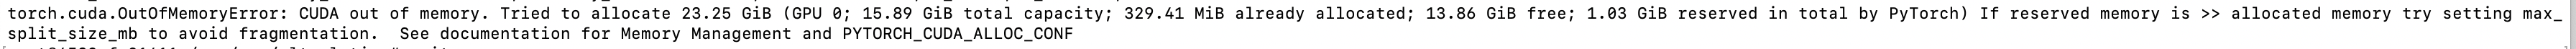

 - [yolov8 GitHub issues](https://github.com/ultralytics/ultralytics/issues/784)

##### run#02 :: good!

```BASH
yolo segment train data=imp_class.yaml model=yolov8n-seg.pt workers=1 epochs=3 imgsz=480 batch=2 cache=True save=True save_period=1
```

##### run#03 :: refinement

```BASH
yolo segment train data=imp_class.yaml model=yolov8n-seg.pt workers=1 epochs=100 imgsz=640 batch=2 cache=True save=True save_period=1
```